In [33]:
import xarray as xr
import numpy as np
from minisom import MiniSom
import pandas as pd
from sklearn.preprocessing import RobustScaler
import pprint
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec 
import matplotlib.colors as mcolors
from matplotlib import colormaps as cm
import matplotlib.gridspec as gridspec 
import warnings
from matplotlib.colors import ListedColormap, BoundaryNorm


# Ignore all warnings
warnings.filterwarnings("ignore")

from som_utils import read_and_transform, build_scaler, train_som, preprocess_single_sample, classify_single_sample

In [34]:
ds_hail = xr.open_dataset('./Datasets/pper_hail_1979_2023.nc')

In [35]:
prefs = {'filename': "/home/scratch/dwefer/GEFSv12/z500_pwat_cape.nc", 
         'vars': ['gh','pwat','cape'], 'wlon': 220, 'elon': 305, 'nlat': 55, 'slat': 20, 
         'som_config': {'x': 9, 'y': 3,'sigma': 1.5, 'random_seed': 42},
         'som_train': {'num_iteration': 10000, 'random_order': True, 'verbose': True}}

trained_som, trained_scaler, train_info, xr_data = train_som(prefs)


current model configuration
{'input_len': 36423, 'random_seed': 42, 'sigma': 1.5, 'x': 9, 'y': 3}
current training configuration
{'data': array([[-0.66050106, -0.68316907, -0.70958024, ..., -0.35766476,
        -0.39876992, -0.47084543],
       [-0.71175027, -0.7709796 , -0.83132076, ..., -0.07086021,
        -0.05198546, -0.06028149],
       [-0.28915408, -0.28948432, -0.29526958, ..., -0.18498929,
        -0.50052845, -0.7557738 ],
       ...,
       [-0.87913156, -0.8735199 , -0.8690234 , ..., -0.03654437,
        -0.12210999, -0.2225972 ],
       [-0.31367952, -0.29052007, -0.26362565, ..., -0.05541589,
        -0.15135957, -0.25826085],
       [-0.43595633, -0.43200427, -0.43102336, ..., -0.12745726,
        -0.18120788, -0.25345182]], dtype=float32),
 'num_iteration': 10000,
 'random_order': True,
 'verbose': True}
 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 120.40784827480431


In [36]:
winner, flat_node, dist_to_bmu, x_scaled, era5_ds = classify_single_sample(
    filepath='/home/scratch/dwefer/era5/3-10-26_data.nc',
    config=prefs,          # same config used in training
    som=trained_som,             # your already-trained MiniSom
    scaler=trained_scaler,       # the scaler returned from training
    time_index=0                 # choose which time if multiple exist
)

print("Winning node (row, col):", winner)
print("Flat node number:", flat_node)
print("Distance to BMU:", dist_to_bmu)

Winning node (row, col): (5, 2)
Flat node number: 17
Distance to BMU: 128.35851920903048


In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def plot_bmu_vs_era(
    ds_era,
    da_z500,
    da_pwat,
    da_cape,
    prefs,
    winner=None,
    flat_node=None,
    time_index=0,
    dpi=220,
    savepath="./Figures/bmu_vs_era5.png",
):
    v1, v2, v3 = prefs["vars"]

    nx = prefs["som_config"]["x"]
    ny = prefs["som_config"]["y"]

    # Same node ordering you used earlier
    nodes = [(i, j) for i in range(nx) for j in range(ny)]
    node_to_idx = {node: idx for idx, node in enumerate(nodes)}

    if flat_node is None:
        if winner is None:
            raise ValueError("Provide either winner or flat_node.")
        flat_node = node_to_idx[winner]

    if winner is None:
        winner = nodes[flat_node]

    # -----------------------------
    # Pull ERA5 fields from ds_era
    # -----------------------------
    if "time" in ds_era.dims:
        ds_era_plot = ds_era.isel(time=time_index)
    else:
        ds_era_plot = ds_era

    era_z500 = ds_era_plot[v1].transpose("latitude", "longitude").to_numpy()
    era_pwat = ds_era_plot[v2].transpose("latitude", "longitude").to_numpy()
    era_cape = ds_era_plot[v3].transpose("latitude", "longitude").to_numpy()

    lat_era = ds_era_plot["latitude"].values
    lon_era = ds_era_plot["longitude"].values

    lon_era_plot = ((lon_era + 180) % 360) - 180
    lon_era_order = np.argsort(lon_era_plot)
    lon_era_plot = lon_era_plot[lon_era_order]

    era_z500 = era_z500[:, lon_era_order]
    era_pwat = era_pwat[:, lon_era_order]
    era_cape = era_cape[:, lon_era_order]

    # -----------------------------
    # Node coordinates
    # -----------------------------
    lat_node = da_z500["latitude"].values
    lon_node = da_z500["longitude"].values

    # Use a common extent for both panels
    lon_min = float(min(np.nanmin(lon_node), np.nanmin(lon_era_plot)))
    lon_max = float(max(np.nanmax(lon_node), np.nanmax(lon_era_plot)))
    lat_min = float(min(np.nanmin(lat_node), np.nanmin(lat_era)))
    lat_max = float(max(np.nanmax(lat_node), np.nanmax(lat_era)))

    lon_pad = 2.0
    lat_pad = 1.5
    extent = [lon_min - lon_pad, lon_max + lon_pad, lat_min - lat_pad, lat_max + lat_pad]

    proj = ccrs.LambertConformal()
    pc = ccrs.PlateCarree()

    # Keep PWAT color scaling consistent across both panels
    pwat_min = float(min(np.nanmin(da_pwat.values), np.nanmin(era_pwat)))
    pwat_max = float(max(np.nanmax(da_pwat.values), np.nanmax(era_pwat)))
    norm_pwat = mcolors.Normalize(vmin=pwat_min, vmax=pwat_max)

    fig, axs = plt.subplots(
        1, 2,
        figsize=(10.5, 4.6),
        dpi=dpi,
        subplot_kw={"projection": proj},
        constrained_layout=False
    )

    mappable_p = None

    # =========================================
    # Left panel: BMU node composite
    # =========================================
    ax = axs[0]
    ax.set_extent(extent, crs=pc)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6)
    ax.add_feature(cfeature.STATES, linewidth=0.4)

    mappable_p = da_pwat.isel(node=flat_node).plot.contourf(
        ax=ax,
        transform=pc,
        levels=levels,
        cmap=cmap,
        add_colorbar=False,
        norm=norm_pwat,
        extend="both"
    )

    da_z500.isel(node=flat_node).plot.contour(
        ax=ax,
        transform=pc,
        colors="k",
        levels=10,
        linewidths=1,
        add_colorbar=False
    )

    cape_node = da_cape.isel(node=flat_node).values

    if np.isfinite(cape_node).any():
        cape_min = float(np.nanmin(cape_node))
        cape_max = float(np.nanmax(cape_node))

        if cape_max > 500:
            low0 = min(cape_min, 499.999)
            high2 = max(cape_max, 1000.001)

            with plt.rc_context({"hatch.color": "red", "hatch.linewidth": 0.1}):
                ax.contourf(
                    lon_node,
                    lat_node,
                    cape_node,
                    levels=[low0, 500, 1000, high2],
                    hatches=[None, "////", "xxxx"],
                    colors="none",
                    transform=pc
                )

                ax.contour(
                    lon_node,
                    lat_node,
                    cape_node,
                    levels=[500],
                    colors="red",
                    linewidths=0.5,
                    transform=pc
                )

                if cape_max > 1000:
                    ax.contour(
                        lon_node,
                        lat_node,
                        cape_node,
                        levels=[1000],
                        colors="red",
                        linewidths=0.5,
                        transform=pc
                    )

    ax.set_title(f"BMU Node {flat_node}  ({winner[0]}, {winner[1]})", fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("")

    # =========================================
    # Right panel: ERA5 case
    # =========================================
    ax = axs[1]
    ax.set_extent(extent, crs=pc)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6)
    ax.add_feature(cfeature.STATES, linewidth=0.4)

    mappable_p = ax.contourf(
        lon_era_plot,
        lat_era,
        era_pwat,
        levels=levels,
        cmap=cmap,
        norm=norm_pwat,
        extend="both",
        transform=pc
    )

    ax.contour(
        lon_era_plot,
        lat_era,
        era_z500,
        levels=10,
        colors="k",
        linewidths=1,
        transform=pc
    )

    if np.isfinite(era_cape).any():
        cape_min = float(np.nanmin(era_cape))
        cape_max = float(np.nanmax(era_cape))

        if cape_max > 500:
            low0 = min(cape_min, 499.999)
            high2 = max(cape_max, 1000.001)

            with plt.rc_context({"hatch.color": "red", "hatch.linewidth": 0.1}):
                ax.contourf(
                    lon_era_plot,
                    lat_era,
                    era_cape,
                    levels=[low0, 500, 1000, high2],
                    hatches=[None, "////", "xxxx"],
                    colors="none",
                    transform=pc
                )

                ax.contour(
                    lon_era_plot,
                    lat_era,
                    era_cape,
                    levels=[500],
                    colors="red",
                    linewidths=0.5,
                    transform=pc
                )

                if cape_max > 1000:
                    ax.contour(
                        lon_era_plot,
                        lat_era,
                        era_cape,
                        levels=[1000],
                        colors="red",
                        linewidths=0.5,
                        transform=pc
                    )

    if "time" in ds_era.dims:
        time_label = str(ds_era["time"].isel(time=time_index).values)
        ax.set_title(f"ERA5 Case\n{time_label}", fontsize=14)
    else:
        ax.set_title("ERA5 Case", fontsize=14)

    ax.set_xlabel("")
    ax.set_ylabel("")

    # Layout + shared colorbar
    fig.subplots_adjust(
        left=0.06, right=0.98, top=0.90, bottom=0.18,
        wspace=0.04, hspace=0.02
    )

    cax = fig.add_axes([0.22, 0.10, 0.56, 0.04])
    cb = fig.colorbar(mappable_p, cax=cax, orientation="horizontal", extend="both")
    cb.set_label("PWAT (mm)", fontsize=13)
    cb.ax.tick_params(labelsize=11)

    plt.show()
    fig.savefig(savepath, dpi=dpi, bbox_inches="tight")

In [38]:
som_data = train_info["som_train"]["data"]

nx = prefs["som_config"]["x"]
ny = prefs["som_config"]["y"]
n_nodes = nx * ny

v1, v2, v3 = prefs["vars"] 

spatial_dims = {"latitude", "longitude"}
sample_dims = [d for d in xr_data[v1].dims if d not in spatial_dims]

if len(sample_dims) != 1:
    raise ValueError(
        f"Expected exactly one non-spatial/sample dimension, got {xr_data[v1].dims}"
    )

sample_dim = sample_dims[0]

z500_all = xr_data[v1].transpose(sample_dim, "latitude", "longitude").to_numpy()
pwat_all = xr_data[v2].transpose(sample_dim, "latitude", "longitude").to_numpy()
cape_all = xr_data[v3].transpose(sample_dim, "latitude", "longitude").to_numpy()

lat = xr_data["latitude"].values
lon = xr_data["longitude"].values
n_samples, nlat, nlon = z500_all.shape

lon_plot = ((lon + 180) % 360) - 180
lon_order = np.argsort(lon_plot)
lon_plot = lon_plot[lon_order]

z500_all = z500_all[:, :, lon_order]
pwat_all = pwat_all[:, :, lon_order]
cape_all = cape_all[:, :, lon_order]

winmap = trained_som.win_map(som_data, return_indices=True)

freq_dict = {node: len(idxs) for node, idxs in winmap.items()}

nodes = [(i, j) for i in range(nx) for j in range(ny)]
node_to_idx = {node: idx for idx, node in enumerate(nodes)}

z500_avg_data = np.full((n_nodes, nlat, nlon), np.nan, dtype=np.float32)
pwat_avg_data = np.full((n_nodes, nlat, nlon), np.nan, dtype=np.float32)
cape_avg_data = np.full((n_nodes, nlat, nlon), np.nan, dtype=np.float32)

for node in nodes:
    node_idx = node_to_idx[node]
    member_idx = winmap.get(node, [])

    if len(member_idx) == 0:
        continue

    member_idx = np.asarray(member_idx, dtype=int)

    z500_avg_data[node_idx] = np.nanmean(z500_all[member_idx], axis=0)
    pwat_avg_data[node_idx] = np.nanmean(pwat_all[member_idx], axis=0)
    cape_avg_data[node_idx] = np.nanmean(cape_all[member_idx], axis=0)

da_z500 = xr.DataArray(
    z500_avg_data,
    dims=("node", "latitude", "longitude"),
    coords={"node": np.arange(n_nodes), "latitude": lat, "longitude": lon_plot},
    name=v1
)

da_pwat = xr.DataArray(
    pwat_avg_data,
    dims=("node", "latitude", "longitude"),
    coords={"node": np.arange(n_nodes), "latitude": lat, "longitude": lon_plot},
    name=v2
)

da_cape = xr.DataArray(
    cape_avg_data,
    dims=("node", "latitude", "longitude"),
    coords={"node": np.arange(n_nodes), "latitude": lat, "longitude": lon_plot},
    name=v3
)

ds_era = xr.open_dataset('/home/scratch/dwefer/era5/3-10-26_data.nc')

In [39]:
from matplotlib.colors import ListedColormap

colors = [
    "#885c1e", "#a9834b", "#c1a779", "#d9cba7", "#f1f0d6",
    "#d6e6bd", "#bcdda4", "#a3d48d", "#89ca75", "#73c05d",
    "#50aa2d", "#1d4d06", "#6ea0ad", "#5a848d", "#44686d",
    "#2f4b4d", "#182b2b", "#666698", "#5a568d", "#4d4680",
    "#3f3575", "#7e7e00", "#9c9d00", "#bcbd00", "#dcdd00",
    "#fbfc00"
]

levels = [i * 2.5 for i in range(27)]
cmap = ListedColormap(colors)

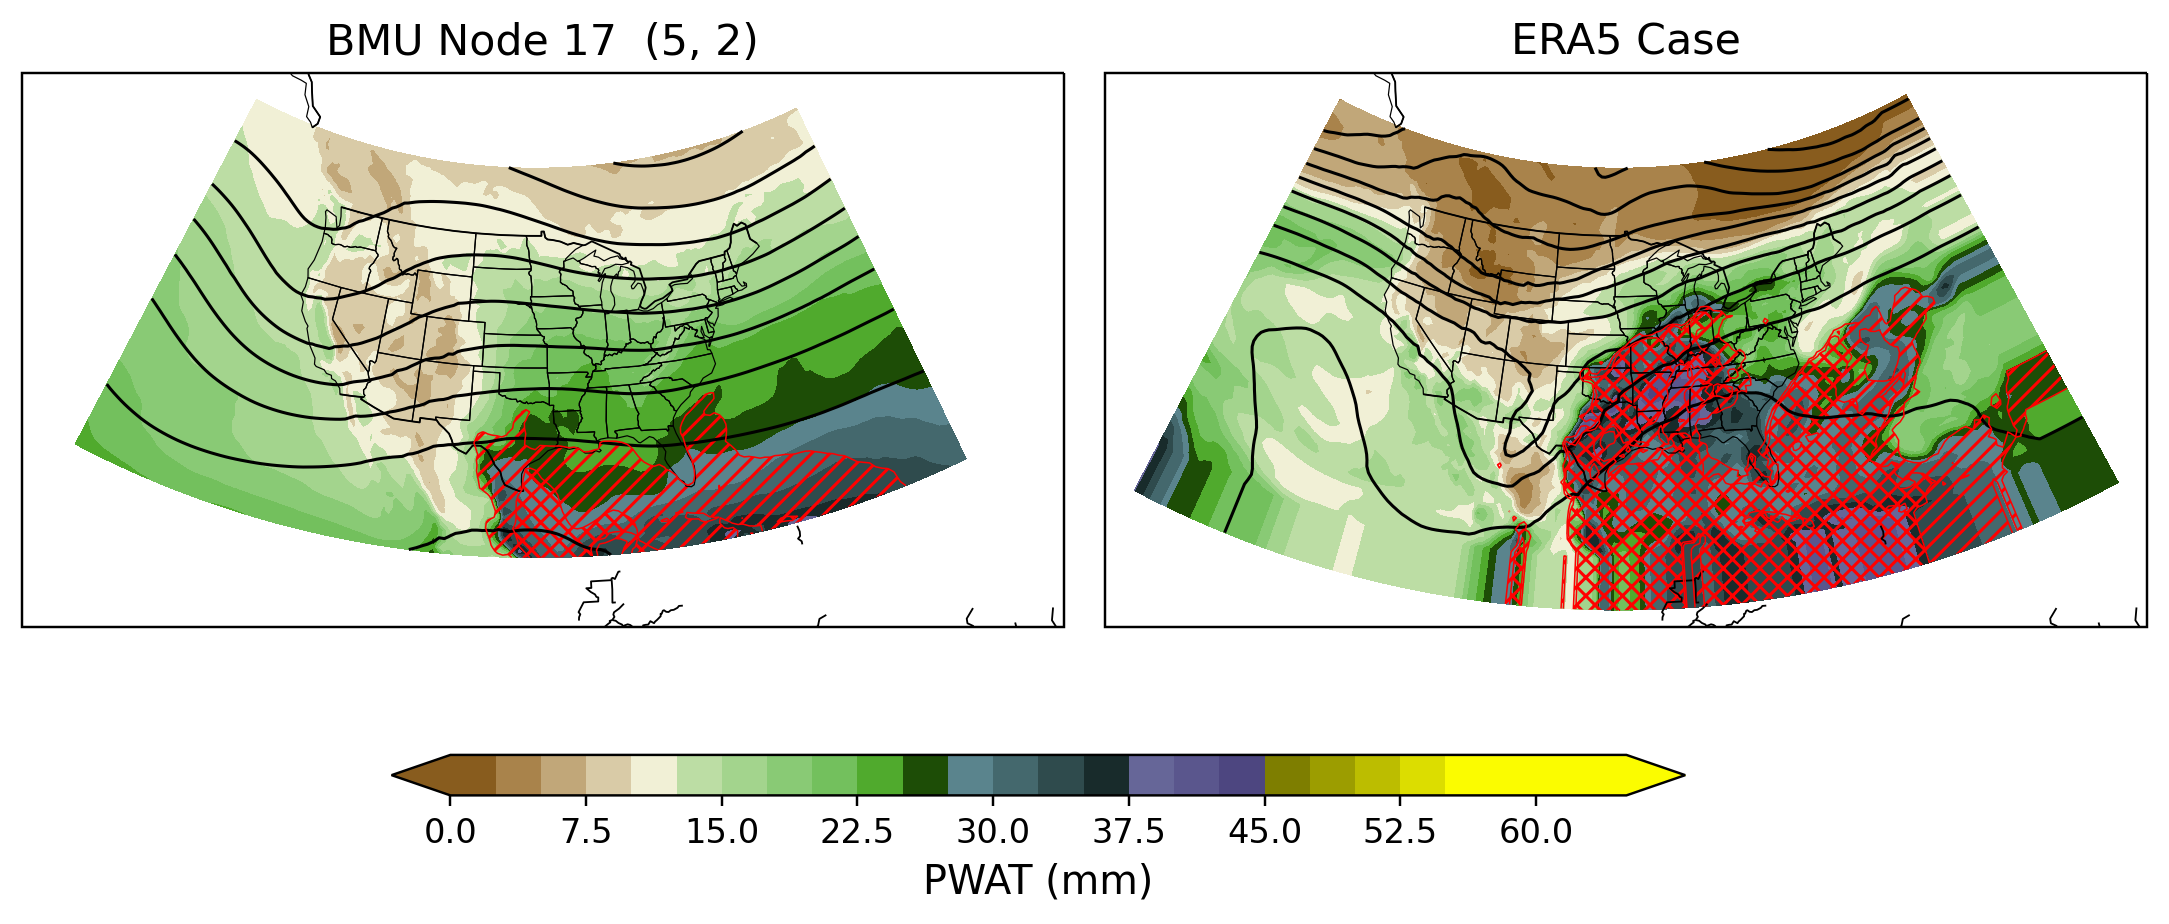

In [40]:
plot_bmu_vs_era(
    ds_era=ds_era,
    da_z500=da_z500,
    da_pwat=da_pwat,
    da_cape=da_cape,
    prefs=prefs,
    winner=winner,          # or use flat_node=flat_node
    flat_node=flat_node,    # optional if winner already provided
    time_index=0,
    savepath="./Figures/bmu_vs_era5.png",
)

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_bmu_mean_pper(
    winner,
    winmap,
    xr_data,
    ds_hail,
    dpi=100,
    savepath="./Figures/bmu_mean_hail.png",
):
    colors = [
        "#f4d71a",
        "#eb973d",
        "#bf4c78",
        "#5811a7",
        "#170f88",
        "#07d7f7"
    ]
    levels = [0.1, 0.5, 2.0, 5.0, 10.0, 15.0, 20.0]

    spatial_dims = {"latitude", "longitude"}
    sample_dims = [d for d in xr_data.dims if d not in spatial_dims]

    if len(sample_dims) != 1:
        raise ValueError(
            f"Expected exactly one non-spatial/sample dimension in xr_data, got {xr_data.dims}"
        )

    sample_dim = sample_dims[0]

    if winner not in winmap:
        raise ValueError(f"BMU node {winner} not found in winmap.")

    idx_list = np.asarray(winmap[winner], dtype=int)

    if idx_list.size == 0:
        raise ValueError(f"BMU node {winner} has no members.")

    nodesel = xr_data.isel({sample_dim: idx_list})

    # shift back a day because PPER is 12z–12z and dataset is 0z
    time_sel = (
        nodesel[sample_dim].values - np.timedelta64(1, "D")
    ).astype("datetime64[D]").astype(str)

    ds_hail_sel = ds_hail.sel(time=time_sel, method="nearest")
    hail_mean = ds_hail_sel.p_perfect_hail.mean(dim="time")

    fig, ax = plt.subplots(
        1, 1,
        figsize=(7.5, 4.8),
        dpi=dpi,
        subplot_kw={"projection": ccrs.LambertConformal()},
        constrained_layout=False
    )

    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.add_feature(cfeature.LAKES)
    ax.set_extent([-122, -67, 20, 50], crs=ccrs.PlateCarree())

    cm_hail = ax.contourf(
        ds_hail.lon,
        ds_hail.lat,
        hail_mean,
        colors=colors,
        levels=levels,
        transform=ccrs.PlateCarree(),
    )

    ax.contour(
        ds_hail.lon,
        ds_hail.lat,
        hail_mean,
        levels=levels,
        transform=ccrs.PlateCarree(),
        linewidths=0.7,
        colors="k",
    )

    ax.set_title(
        f"Mean Practically Perfect Hail Risk\nBMU Node {winner}",
        fontsize=15
    )

    cbar = fig.colorbar(cm_hail, ax=ax, orientation="horizontal", pad=0.06, shrink=0.75)
    cbar.set_label("Mean Practically Perfect Hail Risk (%)", fontsize=13)
    cbar.ax.tick_params(labelsize=11)

    plt.show()
    fig.savefig(savepath, dpi=dpi, bbox_inches="tight")

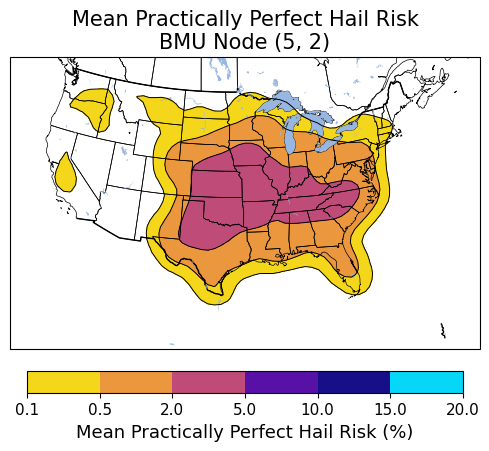

In [42]:
plot_bmu_mean_pper(
    winner=winner,
    winmap=winmap,
    xr_data=xr_data,
    ds_hail=ds_hail,
    savepath="./Figures/bmu_mean_hail.png",
)

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def standardized_anomaly(node_mean, clim_mean, clim_std, eps=1e-12):
    return (node_mean - clim_mean) / (clim_std.where(clim_std > eps))


def plot_bmu_std_anom_pper(
    winner,
    winmap,
    xr_data,
    ds_hail,
    prefs=None,
    dpi=300,
    savepath="./Figures/bmu_stdanom_hail.png",
):
    anom_levels = np.arange(-2, 2.5, 0.5)

    # infer sample dimension the same way as before
    if prefs is not None:
        v1 = prefs["vars"][0]
        sample_dims = [d for d in xr_data[v1].dims if d not in {"latitude", "longitude"}]
    else:
        sample_dims = [d for d in xr_data.dims if d not in {"latitude", "longitude"}]

    if len(sample_dims) != 1:
        raise ValueError(
            f"Expected exactly one non-spatial/sample dimension, got {sample_dims}"
        )

    sample_dim = sample_dims[0]

    if winner not in winmap:
        raise ValueError(f"BMU node {winner} not found in winmap.")

    idx_list = np.asarray(winmap[winner], dtype=int)

    if idx_list.size == 0:
        raise ValueError(f"BMU node {winner} has no members.")

    nodesel = xr_data.isel({sample_dim: idx_list})

    # shift back a day because PPER is 12z–12z and dataset is 0z
    time_sel = (
        nodesel[sample_dim].values - np.timedelta64(1, "D")
    ).astype("datetime64[D]").astype(str)

    ds_hail_sel = ds_hail.sel(time=time_sel, method="nearest")

    hail_node_mean = ds_hail_sel["p_perfect_hail"].mean(dim="time")
    clim_mean = ds_hail["p_perfect_hail"].mean(dim="time")
    clim_std = ds_hail["p_perfect_hail"].std(dim="time")

    hail_anom = standardized_anomaly(hail_node_mean, clim_mean, clim_std)

    fig, ax = plt.subplots(
        1, 1,
        figsize=(6.5, 4.8),
        dpi=dpi,
        subplot_kw={"projection": ccrs.LambertConformal()},
        constrained_layout=False
    )

    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.add_feature(cfeature.LAKES)
    ax.set_extent([-122, -67, 20, 50], crs=ccrs.PlateCarree())

    mappable = ax.contourf(
        ds_hail.lon,
        ds_hail.lat,
        hail_anom,
        levels=anom_levels,
        cmap="RdBu_r",
        extend="both",
        transform=ccrs.PlateCarree(),
    )

    ax.contour(
        ds_hail.lon,
        ds_hail.lat,
        hail_anom,
        levels=anom_levels,
        linewidths=0.7,
        colors="k",
        transform=ccrs.PlateCarree(),
    )

    ax.set_title(f"BMU Node {winner}", fontsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("")

    fig.subplots_adjust(left=0.07, right=0.98, top=0.92, bottom=0.16)

    bb = ax.get_position()
    cb_width = (bb.x1 - bb.x0) * 0.65
    cb_height = 0.035
    cb_x = bb.x0
    cb_y = 0.09

    cax = fig.add_axes([cb_x, cb_y, cb_width, cb_height])
    cb = fig.colorbar(mappable, cax=cax, orientation="horizontal", extend="both")
    cb.set_label("Standardized anomaly (σ)", fontsize=15)
    cb.ax.tick_params(labelsize=13)

    plt.show()
    fig.savefig(savepath, dpi=dpi, bbox_inches=None)

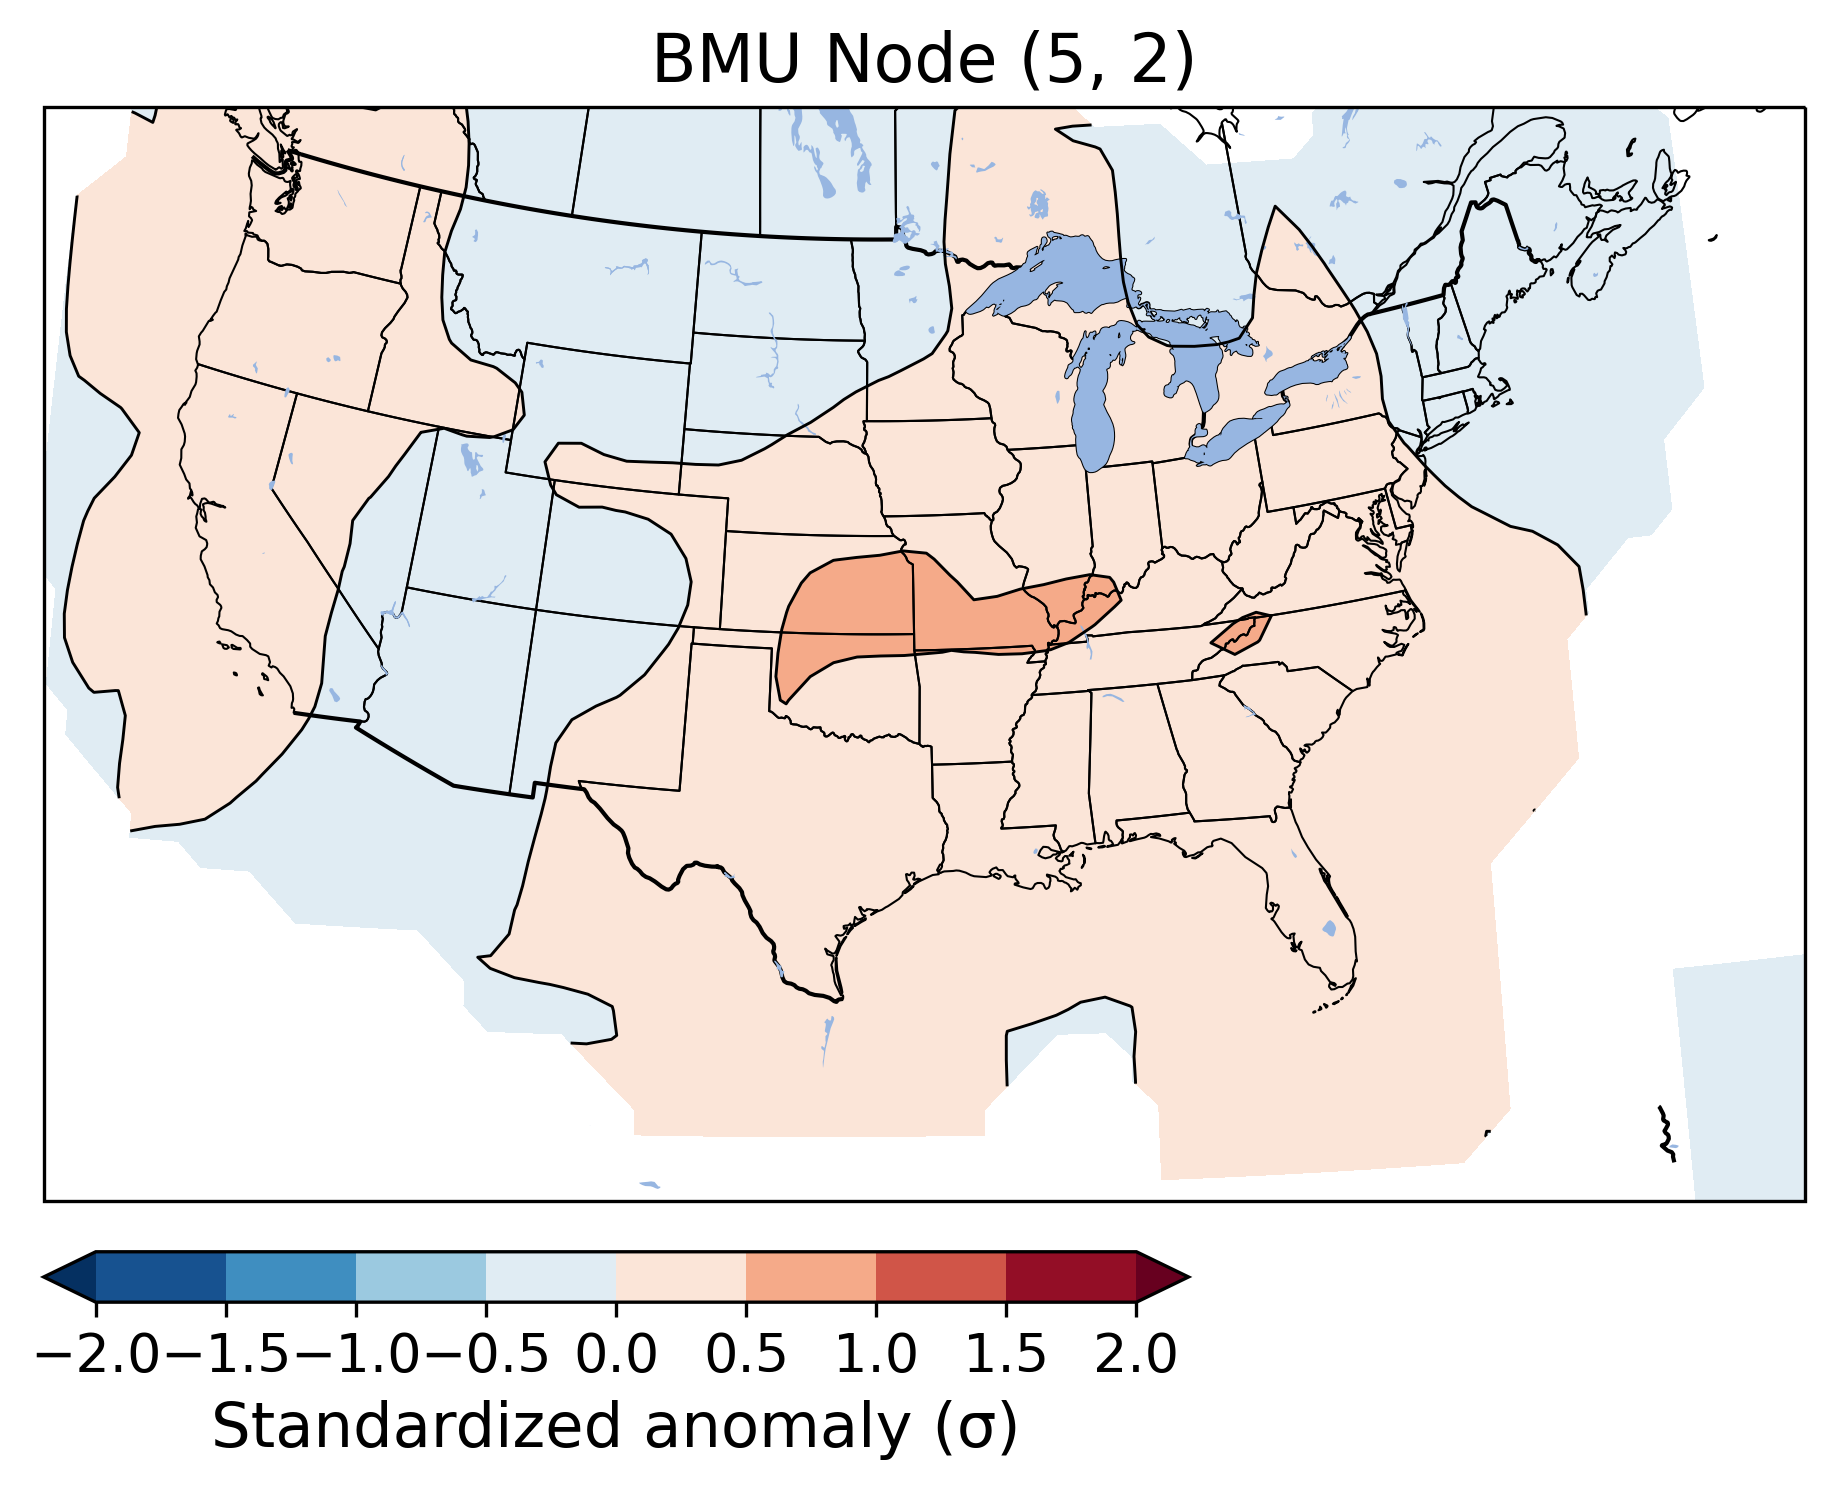

In [44]:
plot_bmu_std_anom_pper(
    winner=winner,
    winmap=winmap,
    xr_data=xr_data,
    ds_hail=ds_hail,
    prefs=prefs,   # optional but recommended if xr_data is a Dataset
    savepath="./Figures/bmu_stdanom_hail.png",
)

In [45]:
def plot_bmu_max_pper(
    winner,
    winmap,
    xr_data,
    ds_hail,
    dpi=100,
    savepath="./Figures/bmu_max_hail.png",
):
    colors = [
        "#f4d71a",
        "#eb973d",
        "#bf4c78",
        "#5811a7",
        "#170f88",
        "#07d7f7"
    ]
    levels = [5, 15, 30, 45, 60, 75, 100]

    spatial_dims = {"latitude", "longitude"}
    sample_dims = [d for d in xr_data.dims if d not in spatial_dims]

    if len(sample_dims) != 1:
        raise ValueError(
            f"Expected exactly one non-spatial/sample dimension in xr_data, got {xr_data.dims}"
        )

    sample_dim = sample_dims[0]

    if winner not in winmap:
        raise ValueError(f"BMU node {winner} not found in winmap.")

    idx_list = np.asarray(winmap[winner], dtype=int)

    if idx_list.size == 0:
        raise ValueError(f"BMU node {winner} has no members.")

    nodesel = xr_data.isel({sample_dim: idx_list})

    # shift back a day because PPER is 12z–12z and dataset is 0z
    time_sel = (
        nodesel[sample_dim].values - np.timedelta64(1, "D")
    ).astype("datetime64[D]").astype(str)

    ds_hail_sel = ds_hail.sel(time=time_sel, method="nearest")
    hail_mean = ds_hail_sel.p_perfect_hail.max(dim="time")

    fig, ax = plt.subplots(
        1, 1,
        figsize=(7.5, 4.8),
        dpi=dpi,
        subplot_kw={"projection": ccrs.LambertConformal()},
        constrained_layout=False
    )

    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.add_feature(cfeature.LAKES)
    ax.set_extent([-122, -67, 20, 50], crs=ccrs.PlateCarree())

    cm_hail = ax.contourf(
        ds_hail.lon,
        ds_hail.lat,
        hail_mean,
        colors=colors,
        levels=levels,
        transform=ccrs.PlateCarree(),
    )

    ax.contour(
        ds_hail.lon,
        ds_hail.lat,
        hail_mean,
        levels=levels,
        transform=ccrs.PlateCarree(),
        linewidths=0.7,
        colors="k",
    )

    ax.set_title(
        f"Max Practically Perfect Hail Risk\nBMU Node {winner}",
        fontsize=15
    )

    cbar = fig.colorbar(cm_hail, ax=ax, orientation="horizontal", pad=0.06, shrink=0.75)
    cbar.set_label("Max Practically Perfect Hail Risk (%)", fontsize=13)
    cbar.ax.tick_params(labelsize=11)

    plt.show()
    fig.savefig(savepath, dpi=dpi, bbox_inches="tight")

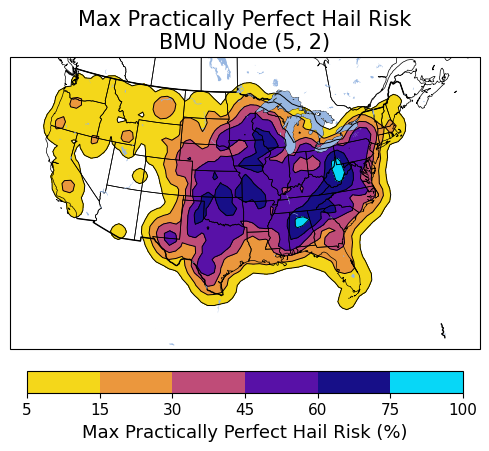

In [46]:
plot_bmu_max_pper(
    winner=winner,
    winmap=winmap,
    xr_data=xr_data,
    ds_hail=ds_hail,
)